# NGsolve example - transformer

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.geom2d import SplineGeometry
from copy import copy


# 1) Geometrie

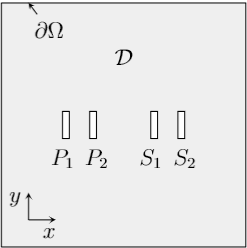

In [2]:
def transformer(NCoils = 1, width = 0.6, height = 0.6, innerDiameterCoil = 4e-2, outerDiameterCoil = 6e-2, heightCoil = 4e-2, hmax = 1e-2):
    ## Geometry generation

    geo = SplineGeometry()
    geo.AddRectangle( p1 = (-width/2, -height/2), p2 = (width/2, height/2), leftdomain = 1, rightdomain = 0, bc = "out")

    if NCoils == 1:
        geo.AddRectangle( p1 = (-outerDiameterCoil/2, -heightCoil/2), p2 = (-innerDiameterCoil/2, heightCoil/2),
        leftdomain = 2, rightdomain = 1 )
        geo.AddRectangle( p1 = (innerDiameterCoil/2, -heightCoil/2), p2 = (outerDiameterCoil/2, heightCoil/2),
        leftdomain = 3, rightdomain = 1 )
        geo.SetMaterial( 2, "S1" )      # conducteur primaire positif
        geo.SetMaterial( 3, "S2" ) 
    elif NCoils == 2:
        th = (outerDiameterCoil - innerDiameterCoil) / 2
        ep = (outerDiameterCoil + innerDiameterCoil) / 2
        geo.AddRectangle( p1 = (-width/2 + (0.3-0.11), -heightCoil/2), p2 = (-width/2 + (0.3-0.11) + th, heightCoil/2),
        leftdomain = 2, rightdomain = 1 )
        geo.AddRectangle( p1 = (-width/2 + (0.3-0.11) + ep, -heightCoil/2), p2 = (-width/2 + (0.3-0.11) + ep + th, heightCoil/2),
        leftdomain = 3, rightdomain = 1 )
        geo.AddRectangle( p1 = (width/2 - (0.3-0.11) - th - ep, -heightCoil/2), p2 = (width/2 - (0.3-0.11) - ep, heightCoil/2),
        leftdomain = 4, rightdomain = 1 )
        geo.AddRectangle( p1 = (width/2 - (0.3-0.11) - th, -heightCoil/2), p2 = (width/2 - (0.3-0.11) , heightCoil/2),
        leftdomain = 5, rightdomain = 1 )
        geo.SetMaterial( 2, "P1" )      # conducteur primaire positif
        geo.SetMaterial( 3, "P2" )      # conducteur primaire négatif
        geo.SetMaterial( 4, "S1" )      # conducteur secondaire positif
        geo.SetMaterial( 5, "S2" )      # conducteur secondaire négatif

# On nomme les différentes zones afin de les repérer plus tard :
    geo.SetMaterial( 1, "D" )       # zone de design
    ngmesh = geo.GenerateMesh( maxh = hmax ) # Maillage avec NetGen
    mesh = Mesh( ngmesh )    # Importation du maillage NetGen dans NgSolve
    return mesh


mesh = transformer(NCoils = 2)
print(f"Nombre de triangles : {mesh.ne}, nombre de noeuds : {mesh.nv}")
Draw(mesh)

Nombre de triangles : 7780, nombre de noeuds : 4011


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

# 2) Equation d'état

On résout : 

$$ S(u,x) =0 $$

In [3]:
jz = 1e6; # amplitude de la densité de courant dans les conducteurs

def solveMag(nu):
    
    # 1) définition de l'espace fonctionnel
    fes = H1(mesh, order=1, dirichlet="out") # à compléter
    a = fes.TrialFunction()
    a_star = fes.TestFunction()
    
    # 2) Définition de la forme bilinéaire
    K = BilinearForm(fes, symmetric=True)
    K += grad(a_star)*nu*grad(a)*dx # à compléter

    # 3) Définition de la forme linéaire
    s = LinearForm(fes)
    s += a_star*jz*dx("P1") - a_star*jz*dx("P2") # à compléter
    
    # 4) Assemblage -> on sort du monde continu pour discrétiser et obtenir le système K * a = s
    K.Assemble() # K est désormais une matrice
    s.Assemble() # s est désormais un vecteur
    
    # 5) Résolution -> la solution formelle s'écrit a = K^-1 * s 
    # (en réalité l'inverse n'est pas explicitement calculée, on utilise une décomposition de Cholesky)
    
    state = GridFunction(fes)  # On déclare que la solution est une fonction définie point par point.
    Kinv = K.mat.Inverse(inverse="sparsecholesky", freedofs=fes.FreeDofs())
    state.vec.data = Kinv * s.vec
    return state, Kinv

nu0 = 1/(4e-7 * np.pi) 
a0, Kinv = solveMag(nu0)
Draw(a0,mesh) # On trace la composante selon z du potentiel vecteur

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [4]:
# Tracé du champ magnétique :

def bField(state):
    return CoefficientFunction((grad(state)[1],-grad(state)[0])) # à compléter

Draw(bField(a0), mesh, vectors = { "grid_size":20})

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [5]:
q = 0
nu0 = 1/(4e-7*np.pi)
nu_f = nu0/1000

def rho2nu(rho):
    return nu0 + (nu_f-nu0)*rho/(q-q*rho+1) # à compléter

def dnuDrho(rho):
    return (nu_f-nu0)*(q+1)/(q-q*rho+1)**2 # à compléter


# 3) Problème adjoint

On définit une fonction objectif $f$, puis on résout le système suivant pour trouver l'état adjoint $p$ :

$$ \partial_u S^* (u,x)  p = -\partial_u f $$

Dans le cas présent, la fonction objectif est le flux qui traverse la bobine secondaire.

In [6]:

def fluxMoyen(state):
    return Integrate ( state, mesh.Materials("S2") )-Integrate ( state, mesh.Materials("S1") ) 


def fObjectif(state):
    return - fluxMoyen(state)

fObjectif(a0)

def solveAdjointState(nu, Kinv):
    
    # 1) définition de l'espace fonctionnel
    fes = H1(mesh, order=1, dirichlet="out") # à compléter
    lambd = fes.TrialFunction()
    a_star = fes.TestFunction()
    
    # 2) Définition de la forme bilinéaire
    #K = BilinearForm(fes, symmetric=True)
    #K += grad(lambd)*nu*grad(a_star)*dx # à compléter

    # 3) Définition de la forme linéaire
    s = LinearForm(fes)
    s += a_star*dx("S2") - a_star*dx("S1") # à compléter
    
    # 4) Assemblage -> on sort du monde continu pour discrétiser et obtenir le système K * a = s
    #K.Assemble() # K est désormais une matrice
    s.Assemble() # s est désormais un vecteur
    
    # 5) Résolution -> la solution formelle s'écrit a = K^-1 * s 
    # (en réalité l'inverse n'est pas explicitement calculée)
    
    adjointState = GridFunction(fes)  # On déclare que la solution est une fonction définie point par point.
    adjointState.vec.data = Kinv * s.vec
    return adjointState

adjoint = solveAdjointState(nu0, Kinv)
Draw(adjoint)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

# 4) Calcul de la dérivée par rapport à $x$

Une fois l'état $u$ et l'état adjoint $p$ obtenus, on peut calculer analytiquement analytiquement
$$d_x f = \partial_x f + p \cdot \partial_x S(u,x)$$

In [7]:
def gradRho(state,adjointState,dnudrho):
    return grad(adjointState) * (dnudrho * grad(state))  # à compléter

Draw(gradRho(a0,adjoint,dnuDrho(0)),mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

# 5) Ajout d'une contrainte de masse et optimisation

In [8]:
def mass(rho):
    return Integrate(rho, mesh)/Integrate(CoefficientFunction((1)), mesh)

def dmassdrho(rho):
    return CoefficientFunction((1))/Integrate(CoefficientFunction((1)), mesh)

In [15]:
## Initialisation

mass_target = 0.1 # Fraction massique cible
beta = 1e-5        # Coefficient de pénalisation
rho0 = 0.5;       # Valeur initiale du champ rho (à faire varier)
alpha = 100       # Pas initial
alpha_min = 1e-4  # Pas minimal
n_max = 200        # Nombre d'itérations de l'algorithme d'optimisation
n = 0

# Définition de la situation initiale
spaceRho = L2(mesh)
rho = GridFunction(spaceRho)
D = GridFunction(spaceRho)
D.Set(mesh.MaterialCF({ "D" : 1}, default=0))
rho.Set(mesh.MaterialCF({ "D" : rho0}, default=0))
rho.vec[:].FV().NumPy()[D.vec[:].FV().NumPy()==1] = rho0

objectiveHistory = [fObjectif(solveMag(rho2nu(rho))[0]) + beta * (mass(rho) - mass_target)**2]
rhoHistory = [copy(rho)]
massHistory = [mass(rho)]


In [16]:

# Tracé du champ de densité initial
scene = Draw(rho, min=0, max=1)

## Boucle d'optimisation (contrainte de masse par pénalisation)

while ( n < n_max and alpha > alpha_min):
    
    # 1) Calcul de l'état physique :
    directState, Kinv = solveMag(rho2nu(rho))
    
    # 2) Calcul de l'état adjoint :
    adjointState = solveAdjointState(rho2nu(rho), Kinv)
    
    # 3) Calcul du gradient :
    gradient = gradRho(directState,adjointState,dnuDrho(rho)[0]) + 2* beta * dmassdrho(rho) * (mass(rho) - mass_target)

    # 4) Mise à jour :
    rho_test = GridFunction(spaceRho)
    rho_test.Set(rho - alpha * gradient)
    n += 1
    
    # 5) Projection :
    rho_test.vec[:].FV().NumPy()[rho_test.vec[:].FV().NumPy()<0] = 0
    rho_test.vec[:].FV().NumPy()[rho_test.vec[:].FV().NumPy()>1] = 1
    rho_test.vec[:].FV().NumPy()[D.vec[:].FV().NumPy()==0] = 0
    
    # 6) Contrôle du pas :
    a_test = solveMag(rho2nu(rho_test))[0]
    objectiveHistory.append(fObjectif(a_test) + beta * (mass(rho_test) - mass_target)**2)
    massHistory.append(mass(rho_test))

    print(f'it n°{n} | f = {objectiveHistory[-1] :.5e} | m = {massHistory[-1]:.5e}        ', end = '\r')
    
    if objectiveHistory[-1] >= objectiveHistory[-2]:
        alpha = alpha/2
        objectiveHistory.pop(); massHistory.pop()
    elif objectiveHistory[-1] < objectiveHistory[-2]:
        alpha = alpha*1.2
        rho = rho_test
        rhoHistory.append(copy(rho))
    scene.Redraw(rho, min=0, max=1)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

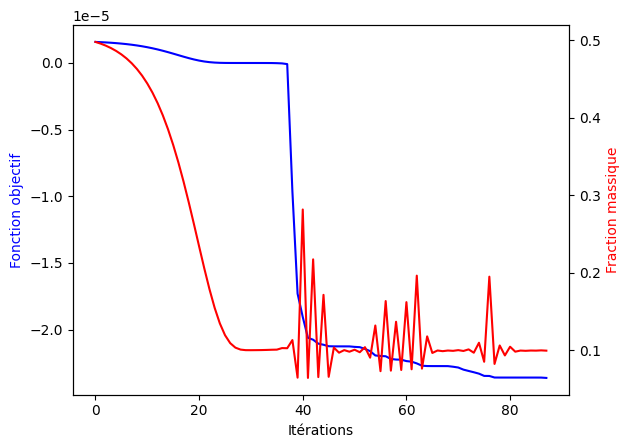

In [11]:
# Evolution de la fonction objectif et de la masse au cours de l'optimisation

ax1 = plt.plot(objectiveHistory, color = 'b')   
plt.ylabel('Fonction objectif', color = 'b')
plt.xlabel('Itérations')
ax2 = plt.gca().twinx()
ax2.plot(massHistory, color = 'r')
plt.ylabel('Fraction massique', color = 'r')
plt.show()